<a href="https://colab.research.google.com/github/wberri13/credit-score-classification/blob/main/notebooks/amex_classification_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

**CHALLENGE SUMMARY**
* This project aims to develop a supervised machine learning model that classifies customers into credit score brackets using their historical credit and bank data. The main goal is to automate the credit score segmentation process, reducing manual work and ensuring consistent, data-driven assessments. The model's success will be evaluated based on its accuracy and ability to perform well with new customers.

**OUR TEAM’S OBJECTIVE**
* Use this classification further in decisioning process as additional input in ML pipeline

**DESIRED OUTCOMES**
* complete analysis of data, model building steps, serving api, and lesson learned , the objective is to become aware of E2E ML pipeline usage in industry



## Data Understanding & Preprocessing

* Data Understanding: Basic stats of the dataset
* Data cleaning: handling missing values, outliers, duplicates, remove  non alphanumeric characters  
* Data transformation: normalization and label encoding , StandardScaler
* Data Visualization:  Various charts to show the relationship between label and features
Suggested tools and libraries for this stage of the project (e.g., Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn


In [ ]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:

import os


In [ ]:
# folder_path = '/content/drive/My Drive/Colab Notebooks/Amex 1B/'
# file_path = os.path.join(folder_path, "train.csv")
# df = pd.read_csv(file_path)

folder_path = '/content/drive/My Drive/Colab Notebooks/'
file_path = os.path.join(folder_path, "train.csv")
df = pd.read_csv(file_path)

# folder_path = '/content/drive/My Drive/Amex 1B/'
# file_path = os.path.join(folder_path, "train.csv")
# df = pd.read_csv(file_path)

/tmp/ipython-input-1859576680.py:7: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Noticed that some columns should be float64, but are object Dtype. Some values may be incorrect

In [ ]:
df = df.drop(["ID", "Customer_ID", "Month", "Name", "SSN"],axis = 1)

Dropping irrelevant columns from our dataset. May need IDs back later

In [ ]:
df[:10]['Age'].unique().tolist()

['23', '-500', '28_', '28']

In [ ]:
df[:10]['Occupation'].unique().tolist()

['Scientist', '_______', 'Teacher']

'Age' column values are treated as strings due to extra '_' being added at the end of our numbers. Also, some of these are negative. What is age? days, years, months, etc.

In [ ]:
df[:10]['Annual_Income'].unique().tolist()

['19114.12', '34847.84']

Similarly, 'Annual Income' values are strings due to extra '_' being added.

In [ ]:
cols_with_nans = df.isna().sum()[df.isna().sum() > 0].index.tolist()
cols_with_nans

['Monthly_Inhand_Salary',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Credit_History_Age',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  object 
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  object 
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  object 
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

In [ ]:
number_cols = df.select_dtypes(include = ('number')).columns.tolist()
object_cols = df.select_dtypes(include = ('object')).columns.tolist()
df[object_cols]

,Age,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",7,11.27,_,809.98,22 Years and 1 Months,No,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,11.27,Good,809.98,NaN,No,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,-500,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",7,_,Good,809.98,22 Years and 3 Months,No,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,6.27,Good,809.98,22 Years and 4 Months,No,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,11.27,Good,809.98,22 Years and 5 Months,No,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",7,11.5,_,502.38,31 Years and 6 Months,No,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",7,11.5,_,502.38,31 Years and 7 Months,No,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",6,11.5,Good,502.38,31 Years and 8 Months,No,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",NaN,11.5,Good,502.38,31 Years and 9 Months,No,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [ ]:


cols_with_errors = object_cols
cols_with_errors
object_cols.remove('Occupation')
object_cols.remove('Type_of_Loan')
object_cols.remove('Credit_Mix')
object_cols.remove('Credit_History_Age')
object_cols.remove('Payment_of_Min_Amount')
object_cols.remove('Payment_Behaviour')
object_cols.remove('Credit_Score')

The following columns are problematic due to being type object when they should only have numbers: 'Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Payment_of_Min_Amount',
 'Amount_invested_monthly',
 'Monthly_Balance'.

The following columns are problematic due to having null values:'Monthly_Inhand_Salary',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Credit_History_Age',
 'Amount_invested_monthly',
 'Monthly_Balance'



In [ ]:
for col in cols_with_errors:
  print(f"First 10 unique values of {col} column:\n", df[col].unique()[:10])

First 10 unique values of Age column:
 ['23' '-500' '28_' '28' '34' '54' '55' '21' '31' '33']
First 10 unique values of Annual_Income column:
 ['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89' '30689.89_'
 '35547.71_' '35547.71' '73928.46' '131313.4']
First 10 unique values of Num_of_Loan column:
 ['4' '1' '3' '967' '-100' '0' '0_' '2' '3_' '2_']
First 10 unique values of Num_of_Delayed_Payment column:
 ['7' nan '4' '8_' '6' '1' '-1' '3_' '0' '8']
First 10 unique values of Changed_Credit_Limit column:
 ['11.27' '_' '6.27' '9.27' '5.42' '7.42' '6.42' '7.1' '11.1' '9.1']
First 10 unique values of Outstanding_Debt column:
 ['809.98' '605.03' '1303.01' '632.46' '943.86' '548.2' '352.16' '1704.18'
 '1377.74' '421.43']
First 10 unique values of Amount_invested_monthly column:
 ['80.41529543900253' '118.28022162236736' '81.699521264648'
 '199.4580743910713' '41.420153086217326' '62.430172331195294'
 '178.3440674122349' '24.785216509052056' '104.291825168246'
 '40.39123782853101']
Firs

For almost every column, we notice '_' and negative values which are causing our numbers to be strings. For Monthly Balance, we don't see anything weird, so it is probably the NaNs that is causing object type

In [ ]:
invalid_col_indices = {col: df.index[(pd.to_numeric(df[col], errors='coerce').isna()) |(pd.to_numeric(df[col], errors='coerce') < 0)].tolist()for col in cols_with_errors}


Using the pd.to_numeric function, we can find the row index with bad values of all columns in our list.

In [ ]:
df['Age'][invalid_col_indices['Age']]

,Age
2,-500
8,28_
54,34_
58,30_
71,24_
...,...
99933,38_
99937,-500
99942,48_
99963,-500


In [ ]:
#So, we find 5825 errors in Age. How many are negative?
df['Age'][invalid_col_indices['Age']].str.startswith('-').sum()

np.int64(886)

There are 886 negative age entries. These are included in the 5825 invalid entries. Later on, lets check how many are above the age of 120. The limit of 120 can be changed if it is too high.


Lets see if we remove the rows with these indices, if the Age column is treated as an float64 type

In [ ]:
new_df = df.drop(invalid_col_indices['Age'], axis = 0)
new_df['Age'] = new_df['Age'].astype(int)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94175 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       94175 non-null  int64  
 1   Occupation                94175 non-null  object 
 2   Annual_Income             94175 non-null  object 
 3   Monthly_Inhand_Salary     80036 non-null  float64
 4   Num_Bank_Accounts         94175 non-null  int64  
 5   Num_Credit_Card           94175 non-null  int64  
 6   Interest_Rate             94175 non-null  int64  
 7   Num_of_Loan               94175 non-null  object 
 8   Type_of_Loan              83454 non-null  object 
 9   Delay_from_due_date       94175 non-null  int64  
 10  Num_of_Delayed_Payment    87585 non-null  object 
 11  Changed_Credit_Limit      94175 non-null  object 
 12  Num_Credit_Inquiries      92322 non-null  float64
 13  Credit_Mix                94175 non-null  object 
 14  Outstanding

It looks like we caught all of the erroneous indices for the age column. How should we treat negative values and values with an extra '_'?


We can try this for all columns to see if we caught all the bad indices.

In [ ]:
total_invalid_indices = [i for col in cols_with_errors for i in invalid_col_indices[col]]
len(total_invalid_indices)


46513

This is around half our dataset, so we should not remove all these values

In [ ]:
half_df = df.drop(total_invalid_indices, axis = 0)
for col in cols_with_errors:
  half_df[col] = half_df[col].astype(float)
pd.concat([half_df.dtypes.to_frame().T, half_df[:3]], ignore_index=True)


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,float64,object,float64,float64,int64,int64,int64,float64,object,int64,...,object,float64,float64,object,object,float64,float64,object,float64,object
1,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,_,809.98,26.82262,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
2,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.45131,Good
3,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172,!@9#%8,340.479212,Good


It looks like all our number types are good. Now, it is time to fix these values

## Task 1 of Milestone 1: Address missing values and outliers




1.   List item
2.   List item



In [ ]:
ages = pd.to_numeric(df['Age'], errors='coerce').dropna()

ages.describe()

,Age
count,95061.000000
mean,110.934505
std,689.407864
min,-500.000000
25%,24.000000
50%,33.000000
75%,42.000000
max,8698.000000


This is terrible for our age data. It has a max of 8698 and a standard deviation of 684.

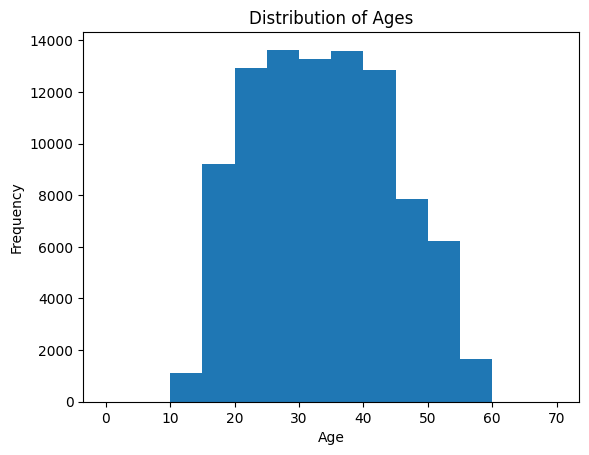

In [ ]:
min_age = 0
max_age =70
bins = np.arange(min_age, max_age + 5, 5)
plt.hist(ages, bins = bins)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Ages')
plt.show()

In [ ]:
for col in cols_with_errors:
  for index in invalid_col_indices[col]:
    val = df.at[index,col]
    if isinstance(val,str):
      if col == "age":
          # If value contains '-' or '__-' → replace with 38
          if "-" in val or "__-" in val:
              df.at[index, col] = '38'
      else:
        val = val.rstrip('_')
        val = val.lstrip('-')
        val = val.lstrip('_')
        df.at[index,col] = val
print(df['Age'].isna().sum())


0


In [ ]:
ages = pd.to_numeric(df['Age'], errors='coerce')
ages = ages.dropna()
ages.describe()


,Age
count,100000.000000
mean,119.509700
std,684.757313
min,14.000000
25%,25.000000
50%,34.000000
75%,42.000000
max,8698.000000


In [ ]:
for col in cols_with_errors:
  print(df[col][invalid_col_indices[col]])

2        500
8         28
54        34
58        30
71        24
        ... 
99933     38
99937    500
99942     48
99963    500
99987     28
Name: Age, Length: 5825, dtype: object
10        34847.84
27        30689.89
32        35547.71
56        34081.38
66       114838.41
           ...    
99959     38321.39
99974     16680.35
99981      37188.1
99993     39628.99
99999     39628.99
Name: Annual_Income, Length: 6980, dtype: object
31       100
34       100
37         0
39       100
53       100
        ... 
99940      0
99958      4
99969    100
99984      5
99987    100
Name: Num_of_Loan, Length: 8661, dtype: object
1        NaN
4        NaN
6          8
10         1
11         3
        ... 
99973    NaN
99974    NaN
99992    NaN
99993    NaN
99998    NaN
Name: Num_of_Delayed_Payment, Length: 10368, dtype: object
2                           
27                      2.01
28                      1.01
29                      3.01
65                          
                ...    

In [ ]:
df[cols_with_errors].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Age                      100000 non-null  object
 1   Annual_Income            100000 non-null  object
 2   Num_of_Loan              100000 non-null  object
 3   Num_of_Delayed_Payment   92998 non-null   object
 4   Changed_Credit_Limit     100000 non-null  object
 5   Outstanding_Debt         100000 non-null  object
 6   Amount_invested_monthly  95521 non-null   object
 7   Monthly_Balance          98800 non-null   object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
delayed_payment = pd.to_numeric(df['Num_of_Delayed_Payment'], errors='coerce')
delayed_payment = delayed_payment.dropna()
delayed_payment.describe()


,Num_of_Delayed_Payment
count,92998.000000
mean,30.946268
std,226.028754
min,0.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,4397.000000


The maximum number of delayed payments is 4397, which seems a little bit off. How many delayed payments can one have?

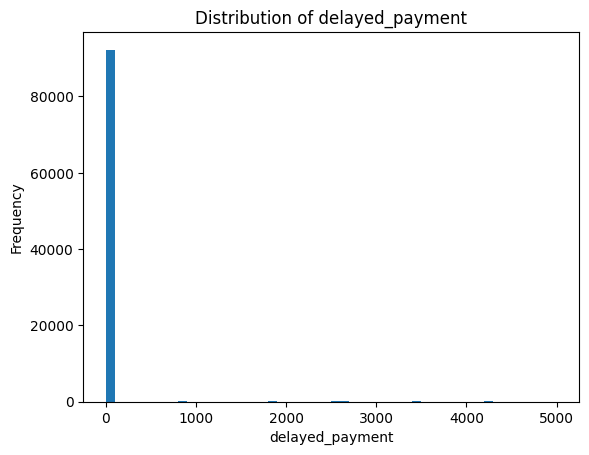

In [ ]:
min_delay = 0
max_delay = 5000
bins = np.arange(min_delay, max_delay + 100, 100)
plt.hist(delayed_payment, bins = bins)
plt.xlabel('delayed_payment')
plt.ylabel('Frequency')
plt.title('Distribution of delayed_payment')
plt.show()

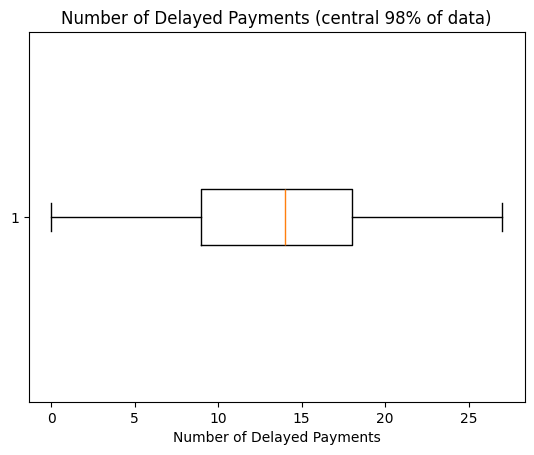

In [ ]:
lower = np.percentile(delayed_payment, 1)
upper = np.percentile(delayed_payment, 99)

delayed_payment_clipped = delayed_payment.clip(lower, upper)
plt.boxplot(delayed_payment_clipped, vert=False)
plt.xlabel('Number of Delayed Payments')
plt.title('Number of Delayed Payments (central 98% of data)')
plt.show()

In [ ]:
delayed_payment[delayed_payment > 100].count()

np.int64(724)

In [ ]:
print("mode", delayed_payment.mode())
print("median", delayed_payment.median())
print("mean", delayed_payment.mean())

mode 0    19.0
Name: Num_of_Delayed_Payment, dtype: float64
median 14.0
mean 30.946267661670145


It looks like there are just a couple of outliers that is skewing our data. We should definitely perform median replacement

In [ ]:
df['Num_of_Delayed_Payment'] = pd.to_numeric(df['Num_of_Delayed_Payment'], errors = 'coerce')
median_val = df['Num_of_Delayed_Payment'].median(skipna=True)
print(median_val)

14.0


In [ ]:
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(median_val)

In [ ]:
df['Num_of_Delayed_Payment'].describe()

,Num_of_Delayed_Payment
count,100000.000000
mean,29.759690
std,218.014703
min,0.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,4397.000000


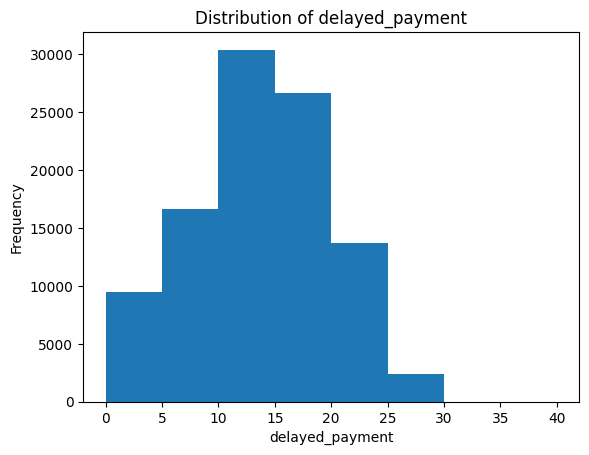

In [ ]:
min_delay = 0
max_delay = 40
bins = np.arange(min_delay, max_delay + 5, 5)
plt.hist(df['Num_of_Delayed_Payment'], bins = bins)
plt.xlabel('delayed_payment')
plt.ylabel('Frequency')
plt.title('Distribution of delayed_payment')
plt.show()

In [ ]:
print((df['Num_of_Delayed_Payment'] > 40).sum())


736


Should be 736 values that are skewing our data, the real range should be 0-30

In [ ]:
amount_invested_monthly = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')
amount_invested_monthly = amount_invested_monthly.dropna()
amount_invested_monthly.describe()


,Amount_invested_monthly
count,95521.000000
mean,637.412998
std,2043.319327
min,0.000000
25%,74.534002
50%,135.925682
75%,265.731733
max,10000.000000


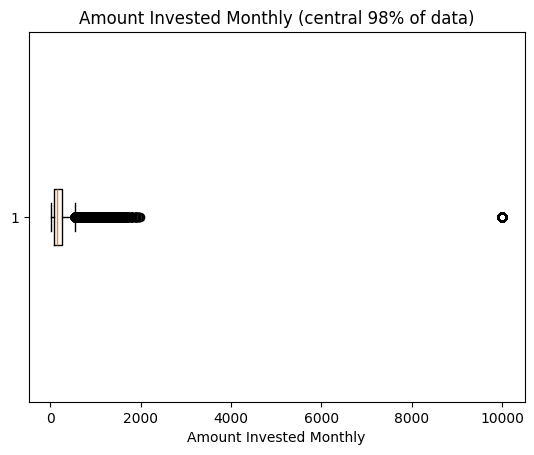

In [ ]:
lower = np.percentile(amount_invested_monthly, 1)
upper = np.percentile(amount_invested_monthly, 99)

amount_invested_monthly_clipped = amount_invested_monthly.clip(lower, upper)
plt.boxplot(amount_invested_monthly_clipped, vert=False)
plt.xlabel('Amount Invested Monthly')
plt.title('Amount Invested Monthly (central 98% of data)')
plt.show()

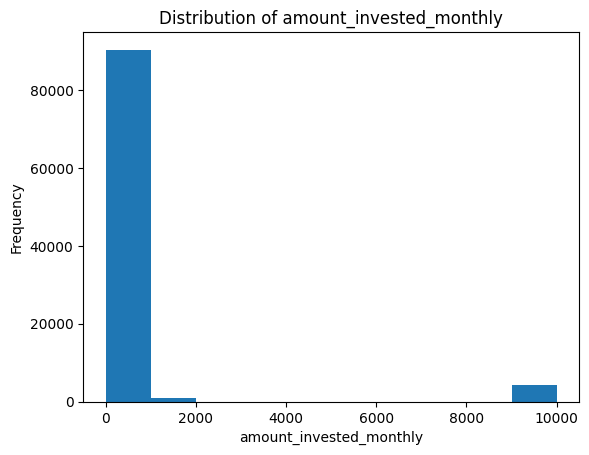

In [ ]:
min_invest_amount = 0
max_invest_amount = 10000
bins = np.arange(min_invest_amount, max_invest_amount + 1000, 1000)
plt.hist(amount_invested_monthly, bins = bins)
plt.xlabel('amount_invested_monthly')
plt.ylabel('Frequency')
plt.title('Distribution of amount_invested_monthly')
plt.show()

These outliers are more plausible, it could be the very wealthy investing a lot

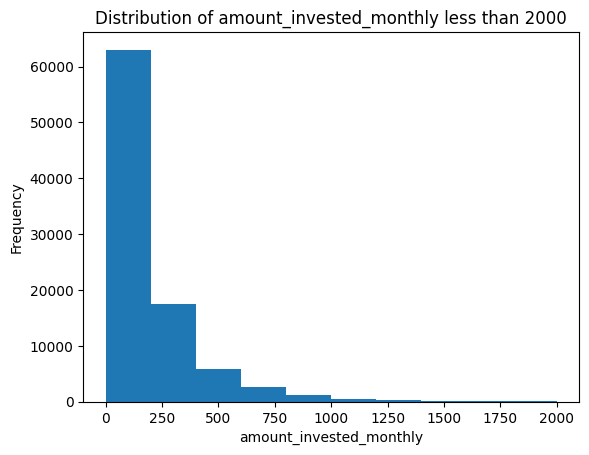

In [ ]:
min_invest_amount = 0
max_invest_amount = 2000
bins = np.arange(min_invest_amount, max_invest_amount + 200, 200)
plt.hist(amount_invested_monthly, bins = bins)
plt.xlabel('amount_invested_monthly')
plt.ylabel('Frequency')
plt.title('Distribution of amount_invested_monthly less than 2000')
plt.show()

In [ ]:
amount_invested_monthly[amount_invested_monthly > 2000].count()

np.int64(4305)

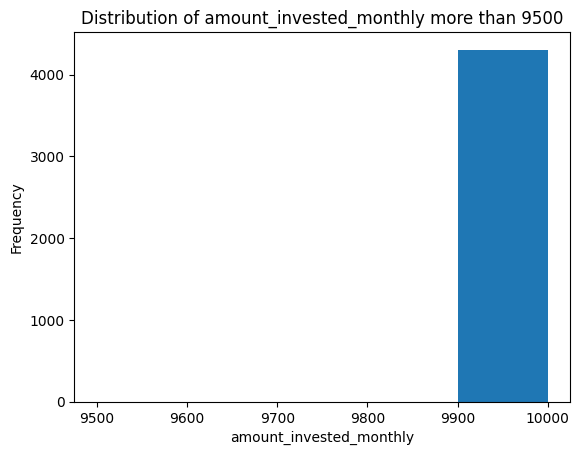

In [ ]:
min_invest_amount = 9500
max_invest_amount = 10000
bins = np.arange(min_invest_amount, max_invest_amount + 100, 100)
plt.hist(amount_invested_monthly, bins = bins)
plt.xlabel('amount_invested_monthly')
plt.ylabel('Frequency')
plt.title('Distribution of amount_invested_monthly more than 9500')
plt.show()

In [ ]:
print("mean", amount_invested_monthly.mean())
print("mode", amount_invested_monthly.mode())
print("median", amount_invested_monthly.median())

mean 637.4129984078688
mode 0    10000.0
Name: Amount_invested_monthly, dtype: float64
median 135.92568154608836


In [ ]:
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(median_val)

TypeError: 'value' must be an instance of str or bytes, not a float

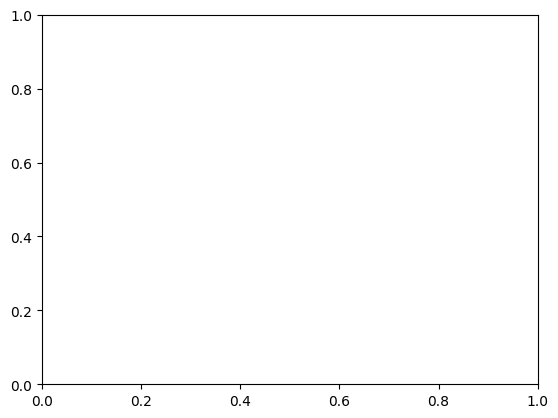

In [ ]:
min_invest_amount = 0
max_invest_amount = 2000
bins = np.arange(min_invest_amount, max_invest_amount + 200, 200)
plt.hist(df['Amount_invested_monthly'], bins = bins)
plt.xlabel('amount_invested_monthly')
plt.ylabel('Frequency')
plt.title('Distribution of amount_invested_monthly less than 2000')
plt.show()

In [ ]:
df['Monthly_Balance'].describe()

In [ ]:
monthly_balance = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
monthly_balance = monthly_balance.dropna()
monthly_balance = monthly_balance.round(2)
monthly_balance[0]
monthly_balance.describe().round(2)


Extremely large outlier -3e+26

In [ ]:
print(monthly_balance[monthly_balance < 0 ].count())
print(monthly_balance[monthly_balance > 2000].count())

In [ ]:
monthly_balance[monthly_balance < 0 ]


These are just bad values. The real range should be 0 - 2000

In [ ]:
lower = np.percentile(monthly_balance, 1)
upper = np.percentile(monthly_balance, 99)

monthly_balance_clipped = monthly_balance.clip(lower, upper)
plt.boxplot(monthly_balance_clipped, vert=False)
plt.xlabel('Monthly Balance')
plt.title('Monthly Balance (central 98% of data)')
plt.show()

In [ ]:
min_balance = 0
max_balance = 2000
bins = np.arange(min_balance, max_balance + 200, 200)
plt.hist(monthly_balance, bins = bins)
plt.xlabel('monthly_balance')
plt.ylabel('Frequency')
plt.title('Distribution of monthly_balance')
plt.show()

In [ ]:
df.loc[df['Monthly_Balance'].notna() & df['Monthly_Balance'].str.startswith('-'), 'Monthly_Balance'] = '0'


In [ ]:
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors = 'coerce')
median_val = df['Monthly_Balance'].median(skipna=True)
mean_val = df['Monthly_Balance'].mean(skipna=True)
print(median_val)
print(mean_val)

In [ ]:
print(monthly_balance.median())
print(monthly_balance.mean())

In [ ]:
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(median_val)

In [ ]:
df[cols_with_errors].info()

All null values and bad values for our number datatypes should be handled by now.

In [ ]:
for col in cols_with_errors:
  print(f"First 10 unique values of {col} column, now changed:\n", df[col].unique()[:10])

In [ ]:
df[:10]['Age'].unique().tolist()

In [ ]:
#lets also get the mode of the age col
mode_age = df['Age'].mode()

df['Age'] = df['Age'].astype(int)
df[:10]['Age'].unique().tolist()

In [ ]:
df['Age'].unique().tolist()
mode_age = df['Age'].mode()[0]
print(mode_age)
df.loc[df['Age'] > 120, 'Age'] = mode_age
df['Age'] = df['Age'].fillna(mode_age)
df[:10]['Age'].unique().tolist()


#lets check how many entries are above 120 years old
#df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
#mode_age = df['Age'].mode(dropna=True)
#print(mode_age)
#df.loc[df['Age'] > 120, 'Age'] = mode_age
#df['Age'] = df['Age'].fillna(mode_age)
#df['Age'] = df['Age'].astype(int)
#df['Age'].unique().tolist()
#greaterThan120 = (df['Age'] > 120).sum()
#print(greaterThan120)
#df['Age'] = df['Age'].fillna(mode_age)
#df['Age'].unique().tolist()
#df.loc[df['Age'] > 120, 'Age'] = mode_age
#df['Age'] = df['Age'].astype(int)
#df['Age'].unique().tolist()


In [ ]:
annual_income = pd.to_numeric(df['Annual_Income'], errors='coerce')
annual_income = annual_income.dropna()
annual_income.describe()


In [ ]:
lower = np.percentile(annual_income, 1)
upper = np.percentile(annual_income, 99)

annual_income_clipped = annual_income.clip(lower, upper)
plt.boxplot(annual_income_clipped, vert=False)
plt.xlabel('Annual Income')
plt.title('Annual Income (central 98% of data)')
plt.show()

In [ ]:
min_income = 0
max_income = 200000
bins = np.arange(min_income, max_income + 10000, 10000)
plt.hist(annual_income, bins = bins)
plt.xlabel('Annual_Income')
plt.ylabel('Frequency')
plt.title('Distribution of Annual_Income Under 200k')
plt.show()

In [ ]:
print(annual_income[annual_income > 200000].count())
annual_income[annual_income > 200000]

Around 1000 people make over 200k a year in our dataset.

In [ ]:
high_income = annual_income[annual_income > 200000]
high_income.describe()

In [ ]:
min_income = 250000
max_income = 2500000
bins = np.arange(min_income, max_income + 100000, 100000)
plt.hist(high_income, bins = bins)
plt.xlabel('Annual_Income')
plt.ylabel('Frequency')
plt.title('Distribution of Annual_Income Over 200k')
plt.show()

Data seems reasonable, we can probably cast it

In [ ]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'])

In [ ]:
df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'])
df['Num_of_Loan'].describe()

In [ ]:
min_loan = 0
max_loan = 100
bins = np.arange(min_loan, max_loan + 10, 10)
plt.hist(df['Num_of_Loan'], bins = bins)
plt.xlabel('Number of Loans')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Loans')
plt.show()

In [ ]:
lower = np.percentile(df['Num_of_Loan'], 1)
upper = np.percentile(df['Num_of_Loan'], 99)

num_of_loan_clipped = df['Num_of_Loan'].clip(lower, upper)
plt.boxplot(num_of_loan_clipped, vert=False)
plt.title('Boxplot of Number of Loans')
plt.show()

In [ ]:
(df['Num_of_Loan'] > 10).sum()

In [ ]:
min_loan = 0
max_loan = 10
bins = np.arange(min_loan, max_loan + 1, 1)
plt.hist(df['Num_of_Loan'], bins = bins)
plt.xlabel('Number of Loans')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Loans Under 10')
plt.show()

In [ ]:
min_loan = 100
max_loan = 105
bins = np.arange(min_loan, max_loan + 1, 1)
plt.hist(df['Num_of_Loan'], bins = bins)
plt.xlabel('Number of Loans')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Loans Between 100 and 105')
plt.show()

These seem unsually large for number of loans, but we will cast

In [ ]:
df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'])

In [ ]:
df[object_cols].info()

In [ ]:
credit_limit = pd.to_numeric(df['Changed_Credit_Limit'], errors='coerce')
credit_limit = credit_limit.dropna()
credit_limit.describe()

Very reasonable range!

In [ ]:
lower = np.percentile(credit_limit, 1)
upper = np.percentile(credit_limit, 99)

credit_limit_clipped = credit_limit.clip(lower, upper)
plt.boxplot(credit_limit_clipped, vert=False)
plt.title('Boxplot of Changed Credit Limit')
plt.show()

In [ ]:
min_credit_limit = 0
max_credit_limit = 40
bins = np.arange(min_credit_limit, max_credit_limit + 1, 1)
plt.hist(credit_limit, bins = bins)
plt.xlabel('Changed Credit Limit')
plt.ylabel('Frequency')
plt.title('Distribution of Changed Credit Limit')
plt.show()

In [ ]:
df['Changed_Credit_Limit'][df['Changed_Credit_Limit'] == '']

There are empty strings in the Changed Credit Limit that were not detected with isna(). Our data is slightly skewed, so we can just replace these with the median

In [ ]:
print(credit_limit.median())

In [ ]:
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', '9.4')

In [ ]:
df['Changed_Credit_Limit'] = pd.to_numeric(df['Changed_Credit_Limit'])
df['Changed_Credit_Limit'].describe()

In [ ]:
outstanding_debt = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')
outstanding_debt = outstanding_debt.dropna()
outstanding_debt.describe()

Very reasonable range for outstanding debt.

In [ ]:
min_debt = 0
max_debt = 5000
bins = np.arange(min_debt, max_debt + 1000, 1000)
plt.hist(outstanding_debt, bins = bins)
plt.xlabel('Outstanding Debt')
plt.ylabel('Frequency')
plt.title('Distribution of Outstanding Debt')
plt.show()

In [ ]:
lower = np.percentile(outstanding_debt, 1)
upper = np.percentile(outstanding_debt, 99)

outstanding_debt_clipped = outstanding_debt.clip(lower, upper)
plt.boxplot(outstanding_debt_clipped, vert=False)
plt.title('Boxplot of Outstanding Debt')
plt.show()


In [ ]:
outstanding_debt[outstanding_debt > 4000].count()

Around 5000 outliers, but still very skewed


In [ ]:
df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'])

In [ ]:
df['Outstanding_Debt'].describe()

In [ ]:
df[object_cols].info()

## Handling 'object' number types

Number columns have been properly casted to appropriate number types and their outliers have been handled. Next, to handle actual number types.



In [ ]:
df.info()

In [ ]:
remaining_number_cols = df.select_dtypes(include='number').drop(columns = object_cols).columns.tolist()
print(remaining_number_cols)

In [ ]:
df['Monthly_Inhand_Salary'].describe()

In [ ]:
min_salary = 0
max_loan = 15000
bins = np.arange(min_loan, max_loan + 1000, 1000)
plt.hist(df['Monthly_Inhand_Salary'], bins = bins)
plt.xlabel('Monthly_Inhand_Salary')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly_Inhand_Salary')
plt.show()

In [ ]:
print(df['Monthly_Inhand_Salary'].median(skipna = True))
print(df['Monthly_Inhand_Salary'].mean(skipna = True))
print(df['Monthly_Inhand_Salary'].mode())
df['Monthly_Inhand_Salary'].fillna(df['Monthly_Inhand_Salary'].median(skipna = True), inplace = True)

In [ ]:
df['Monthly_Inhand_Salary'].isna().sum()

In [ ]:
df['Num_Bank_Accounts'].describe()

In [ ]:
min_num = 0
max_num = 2000
bins = np.arange(min_num, max_num + 100, 100)
plt.hist(df['Num_Bank_Accounts'], bins = bins)
plt.xlabel('Num_Bank_Accounts')
plt.ylabel('Frequency')
plt.title('Distribution of Num_Bank_Accounts')
plt.show()

In [ ]:
min_num = 100
max_num = 2000
bins = np.arange(min_num, max_num + 100, 100)
plt.hist(df['Num_Bank_Accounts'], bins = bins)
plt.xlabel('Num_Bank_Accounts')
plt.ylabel('Frequency')
plt.title('Distribution of Num_Bank_Accounts Over 100')
plt.show()

In [ ]:
df['Num_Credit_Card'].describe()

In [ ]:
min_num = 0
max_num = 1500
bins = np.arange(min_num, max_num + 100, 100)
plt.hist(df['Num_Credit_Card'], bins = bins)
plt.xlabel('Num_Credit_Card')
plt.ylabel('Frequency')
plt.title('Distribution of Num_Credit_Card')
plt.show()

In [ ]:
min_num = 50
max_num = 1500
bins = np.arange(min_num, max_num + 100, 100)
plt.hist(df['Num_Credit_Card'], bins = bins)
plt.xlabel('Num_Credit_Card')
plt.ylabel('Frequency')
plt.title('Distribution of Num_Credit_Card Over 50')
plt.show()

In [ ]:
df['Interest_Rate'].describe()

In [ ]:
min_interest = 0
max_interest = 6000
bins = np.arange(min_interest, max_interest + 100, 100)
plt.hist(df['Interest_Rate'], bins = bins)
plt.xlabel('Interest_Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Interest_Rate')
plt.show()

In [ ]:
min_interest = 100
max_interest = 6000
bins = np.arange(min_interest, max_interest + 100, 100)
plt.hist(df['Interest_Rate'], bins = bins)
plt.xlabel('Interest_Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Interest_Rate over 100')
plt.show()

In [ ]:
df['Delay_from_due_date'].describe()

In [ ]:
df['Num_Credit_Inquiries'].describe()

In [ ]:
min_interest = 0
max_interest = 3000
bins = np.arange(min_interest, max_interest + 300, 300)
plt.hist(df['Num_Credit_Inquiries'], bins = bins)
plt.xlabel('Num_Credit_Inquiries')
plt.ylabel('Frequency')
plt.title('Distribution of Num_Credit_Inquiries')
plt.show()

In [ ]:
min_interest = 300
max_interest = 3000
bins = np.arange(min_interest, max_interest + 300, 300)
plt.hist(df['Num_Credit_Inquiries'], bins = bins)
plt.xlabel('Num_Credit_Inquiries')
plt.ylabel('Frequency')
plt.title('Distribution of Num_Credit_Inquiries Over 300')
plt.show()

In [ ]:

print(df['Num_Credit_Inquiries'].mean(skipna =True))
print(df['Num_Credit_Inquiries'].median(skipna=True))
print(df['Num_Credit_Inquiries'].mode())

In [ ]:
df['Num_Credit_Inquiries'].fillna(df['Num_Credit_Inquiries'].median(skipna=True), inplace = True)

In [ ]:
df['Credit_Utilization_Ratio'].describe()

In [ ]:
df['Total_EMI_per_month'].describe()

In [ ]:
min_EMI = 0
max_EMI = 85000
bins = np.arange(min_EMI, max_EMI + 1000, 10000)
plt.hist(df['Total_EMI_per_month'], bins = bins)
plt.xlabel('Total_EMI_per_month')
plt.ylabel('Frequency')
plt.title('Distribution of Total_EMI_per_month')
plt.show()

In [ ]:
min_EMI = 10000
max_EMI = 85000
bins = np.arange(min_EMI, max_EMI + 1000, 10000)
plt.hist(df['Total_EMI_per_month'], bins = bins)
plt.xlabel('Total_EMI_per_month')
plt.ylabel('Frequency')
plt.title('Distribution of Total_EMI_per_month over 10000')
plt.show()

for the new values, the data is not very normal... should we cap to q3 or something else

In [ ]:
df[object_cols].info()

In [ ]:
df[df.select_dtypes(include = 'number').columns].info()

starting the real object types

In [ ]:
df[df.select_dtypes(include='object').columns].info()

In [ ]:
df['Occupation'].unique().tolist()

In [ ]:
#df = df.drop(df[df['Occupation'] == '_______'].index,axis = 0)


In [ ]:
df['Occupation'].unique().tolist()

In [ ]:
df['Occupation'].value_counts()

In [ ]:
df['Type_of_Loan'][:100].unique().tolist()

Need to one hot encode these, but dropping all nulls for now

In [ ]:
df['Type_of_Loan'].fillna("Unknown", inplace=True)
df['Type_of_Loan'].isna().sum()

In [ ]:
df['Credit_History_Age'][:20].unique().tolist()

One hot encoded and fillna with median at bottom


In [ ]:
df['Credit_Mix'].unique().tolist()

In [ ]:
df['Credit_Mix'].value_counts()

In [ ]:
df['Credit_Score'][:100].unique().tolist()

In [ ]:
#replacing unknown with Standard
df.loc[df['Credit_Mix'] == '_', 'Credit_Mix'] = 'Standard'
df['Credit_Mix'].unique().tolist()

In [ ]:
df['Payment_of_Min_Amount'].unique().tolist()

Nothing looks incorrect here

In [ ]:
df['Payment_Behaviour'].unique().tolist()

In [ ]:
df['Payment_Behaviour'].value_counts()

In [ ]:
df.loc[df['Payment_Behaviour'] == '!@9#%8', 'Payment_Behaviour'] = 'Unknown'
df['Payment_Behaviour'].unique().tolist()

## Handling Object types

The following changes were made to columns with object types:


1.   Occupation: '_______'  -> replaced with unknown
2.   Type of Loan: na -> converted to int and median replaced
3.   Credit mix: '_' -> replaced with unknown
4.   Payment Behaviour: !@9#%8 -> replaced with unknown



In [ ]:
df.info()

In [ ]:
df.isna().sum()
dfPCA = df.copy()

Continuing data exploration, now that df.describe() returns all columns of number types

In [ ]:
df.describe()

## Task 2 of Milestone 1: Standardize categorical variables, normalize numerical features

In [ ]:
df['Credit_History_Age'][:50].unique().tolist()
#should this be converted to a quantitative var?

In [ ]:
df.head()

In [ ]:
#Switched from string to float. I'm not sure why it's being saved as float instead of an int. I can't do the fill na method with floats, but once I figure out how to get this to int, I can implement it
df['Credit_History_Age'].unique().tolist()
def convert_to_months(val):
    if pd.isna(val):
        return np.nan
    parts = val.split()
    years = int(parts[0])
    months = int(parts[3])
    return int(years * 12 + months)
df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_to_months)
df['Credit_History_Age'][:50].unique().tolist()


In [ ]:
df['Credit_History_Age'].describe()

In [ ]:
min_age = 0
max_age = 500
bins = np.arange(min_age, max_age + 100, 50)
plt.hist(df['Credit_History_Age'], bins = bins)
plt.xlabel('Credit_History_Age')
plt.ylabel('Frequency')
plt.title('Distribution of Credit_History_Age')
plt.show()

In [ ]:
df['Credit_History_Age'].fillna(df['Credit_History_Age'].median(skipna = True), inplace = True)
df['Credit_History_Age'].isna().sum()

In [ ]:
df.info()

In [ ]:
# feature engineering : avg spending per quarter
# Reload original data to get Customer_ID and Month for time series calculation
full_df = pd.read_csv(file_path)
df = df.join(full_df[['Customer_ID', 'Month']], how='left').dropna(subset=['Customer_ID', 'Month'])

# Create a numerical month for sorting and sort the data chronologically for each customer
df['Month_Num'] = pd.to_datetime(df['Month'], format='%B').dt.month
df = df.sort_values(by=['Customer_ID', 'Month_Num'])

# Calculate rolling averages over 3, 6, 9, and 12 month windows
spending_col = 'Amount_invested_monthly'
windows = [3, 6, 9, 12]
for window in windows:
    col_name = f'avg_spend_{window}m'
    df[col_name] = df.groupby('Customer_ID')[spending_col].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

# Drop helper columns
df = df.drop(columns=['Customer_ID', 'Month', 'Month_Num'])

In [ ]:
df['Credit_Mix'].value_counts()

In [ ]:
df['Credit_Score'].value_counts()

In [ ]:
# Task 2 : ordinal encoding catagorical featuers
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

# make a copy to compare before/after
df_compare = df[['Credit_Score', 'Credit_Mix']].copy()

# Encode Credit_Score (Poor < Standard < Good)
score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_compare['Credit_Score_Encoded'] = df_compare['Credit_Score'].map(score_map)  # NaN stays NaN

# ord_enc_score = OrdinalEncoder(categories=[['Poor', 'Standard', 'Good']])
# df_compare['Credit_Score_Encoded'] = ord_enc_score.fit_transform(df_compare[['Credit_Score']])





In [ ]:

# Encode Credit_Mix (Bad < Poor < Standard < Good)
mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df_compare['Credit_Mix_Encoded'] = df_compare['Credit_Mix'].map(mix_map)  # NaN stays NaN

# Show first 10 rows before & after
print(" BEFORE & AFTER ENCODING (first 10 rows)")
print(df_compare.head(10))

#  Check unique values (sorted for clarity)
print("\nUnique values in 'Credit_Score_Encoded':", np.sort(df_compare['Credit_Score_Encoded'].unique()))
print("Unique values in 'Credit_Mix_Encoded':", np.sort(df_compare['Credit_Mix_Encoded'].unique()))

In [ ]:
df['Credit_Score'] = df_compare['Credit_Score_Encoded']
df['Credit_Mix'] = df_compare['Credit_Mix_Encoded']
df.head()
print(df['Credit_Score'].unique().tolist())
print(df['Credit_Mix'].unique().tolist())

In [ ]:

# checking the unique values of these catagorical columns before useing one hot encoding
categorical_columns = ['Occupation', 'Type_of_Loan', 'Payment_Behaviour', 'Payment_of_Min_Amount']

for col in categorical_columns:
    print(f"Unique values in '{col}' column:", df[col].unique())
    print(f"Data type of '{col}' column:", df[col].dtype)


In [ ]:
df['Type_of_Loan'][:100].unique().tolist()

In [ ]:
all_loans = set()
for val in df['Type_of_Loan']:
  for loan in val.split(","):
    loan = loan.replace("and", "").strip()
    if (loan):
      all_loans.add(loan)
print(all_loans)

In [ ]:
loan_encoded = pd.DataFrame({
    loan: df["Type_of_Loan"].str.count(loan)
    for loan in all_loans
})
print(loan_encoded.head(1))
print(df['Type_of_Loan'][0])

Hopefully, this captures every type of loan found in each column

In [ ]:
print(df.shape, len(all_loans))
df = pd.concat([df, loan_encoded], axis = 1)
print(df.shape)

In [ ]:

# # get all unique loan types
# df['Type_of_Loan_List'] = df['Type_of_Loan'].apply(lambda x: [i.strip() for i in x.split(',')])
# all_loans = set([loan for sublist in df['Type_of_Loan_List'] for loan in sublist])

# # create binary columns for each loan type
# for loan in all_loans:
#   df[loan] = df['Type_of_Loan_List'].apply(lambda x: 1 if loan in x else 0)

# one hot encode Occupation and payment behavior
df_encoded = pd.get_dummies(df[['Occupation', 'Payment_Behaviour', 'Payment_of_Min_Amount']])

# drop original catagorical columns
df = df.drop(columns=['Occupation', 'Payment_Behaviour', 'Type_of_Loan',  'Payment_of_Min_Amount'])
# can change true false values to 0,1 if needed with this line of code
# One-hot encode 'Occupation' and 'Payment_Behaviour' as integers
#df_encoded = pd.get_dummies(df[['Occupation', 'Payment_Behaviour']].astype(str), drop_first=True).astype(int)
# combine the one hot encoded columns
df = pd.concat([df, df_encoded], axis=1)


print(df.columns)
# printing unique values for each column changed
changed_cols = list(all_loans) + list(df_encoded.columns)

print("\nAfter One-Hot Encoding :")
for col in changed_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Data type:", df[col].dtype)

print("\nShape of dataframe after encoding:", df.shape)


In [ ]:
# normalize numerical features
numeric_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary',
                    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                    'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
                    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
                    'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
                    'Amount_invested_monthly', 'Monthly_Balance']

scaler = StandardScaler()
# calculates the mean and standard deviation of each column & subtracts the mean and divides by the std to standardize the data
# mean = 0, std = 1
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df[numeric_features].describe()

In [ ]:
df.info()

In [ ]:
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df = numeric_df.drop(columns = ['Credit_Mix', 'Credit_Score', 'Student Loan', 'Credit-Builder Loan' , 'Personal Loan', 'Mortgage Loan', 'Debt Consolidation Loan' ,'Home Equity Loan' ,'Auto Loan','Payday Loan'])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size":10}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


I don't know why, but some columns that aren't diagonals have a correlation of 1. I won't include these, but I will consider $|r| \geq .15$ as a strong correlation.

In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
)

strong_corr = corr_pairs[(abs(corr_pairs['Correlation']) > 0.15) & (corr_pairs['Correlation'] != 1)]

strong_corr = strong_corr.sort_values(by='Correlation', key=abs, ascending=False)

print(strong_corr)
print(len(strong_corr))


*6* unique pairwise columns have correlation greater than .15. Let's visualize these

In [ ]:
for _, row in strong_corr.iterrows():
    feature_x = row['Feature_1']
    feature_y = row['Feature_2']
    corr_val = row['Correlation']

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=numeric_df[feature_x], y=numeric_df[feature_y])
    plt.title(f"{feature_x} vs {feature_y} (corr={corr_val:.2f})")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()


In [ ]:
for _, row in strong_corr.iterrows():
    feature_x = row['Feature_1']
    feature_y = row['Feature_2']
    corr_val = row['Correlation']

    plt.figure(figsize=(6, 4))
    plt.hexbin(
        numeric_df[feature_x],
        numeric_df[feature_y],
        gridsize=50,
        cmap='Blues',
        mincnt=1
    )
    plt.colorbar(label='Counts')
    plt.title(f"{feature_x} vs {feature_y} (corr={corr_val:.2f})")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()


In [ ]:
numeric_df_new = numeric_df.copy()
for _, row in strong_corr.iterrows():
    feature_x = row['Feature_1']
    feature_y = row['Feature_2']
    corr_val = row['Correlation']

    new_col_name = f"{feature_x}_x_{feature_y}"
    numeric_df_new[new_col_name] = numeric_df_new[feature_x] * numeric_df_new[feature_y]



In [ ]:
non_numeric_cols = [col for col in df.columns if col not in numeric_df.columns]
non_numeric_df = df[non_numeric_cols]
for col in non_numeric_df.columns:
    plt.figure(figsize=(6,4))
    counts = non_numeric_df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, palette='Set2', hue = counts.index, legend =False )
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


In [ ]:
for col in non_numeric_df.columns:
    if col == 'Credit_Score':
        continue

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, hue='Credit_Score', data=df, palette='Set2')

    plt.title(f'Distribution of {col} by Credit_Score')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


In [ ]:
df.head(50)

In [ ]:
df['Credit_Score']

In [ ]:
from sklearn.preprocessing import StandardScaler

features = df.drop(columns = ['Credit_Score']).columns.tolist()

# Separating out the features
x = df.loc[:, features].values

# Separating out the target
y = df.loc[:,['Credit_Score']].values

# Standardizing the features
x = StandardScaler().fit_transform(x)

pd.DataFrame(x, columns=features)



In [ ]:
df.isna().sum()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])


#PCA Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(principalDf['principal component 1'], principalDf['principal component 2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Samples Projected on First Two Components')
plt.grid(True)
plt.show()


In [ ]:
print(pca.explained_variance_ratio_) #our principal components account fos around 16.8 percent of variation


In [ ]:
pca_full = PCA().fit(x)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Components')
plt.grid(True)
plt.show()
#for pca, its best to have 70-90 percent explained variance

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)
display(loadings.iloc[:, :2])

In [ ]:
from sklearn.preprocessing import StandardScaler

#start from pca copy because it has the non-standardized vals
df0 = dfPCA.copy()

# features/target
y = df0['Credit_Score']
X = df0.drop(columns=['Credit_Score'])

#Need to keep only continuous vars
num = X.select_dtypes(include=['number']).copy()

# get rid of extremes
# winsorize: clip each column at 0.5% and 99.5% percentiles
q_low  = num.quantile(0.005)
q_high = num.quantile(0.995)
num_clip = num.clip(lower=q_low, upper=q_high, axis=1)

# I tried robust scale, the result was worse so i switched to standard scale
Xs = pd.DataFrame(StandardScaler().fit_transform(num_clip),
                  columns=num_clip.columns, index=num_clip.index)

#PCA
pca = PCA(n_components=2, random_state=0)
pc = pca.fit_transform(Xs)
principalDf = pd.DataFrame(pc, columns=['PC1','PC2'], index=Xs.index)

print("explained variance:", pca.explained_variance_ratio_)


This test has an explained variance of 23% which is slightly better than above.
---



In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(principalDf['PC1'], principalDf['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Samples Projected on First Two Components')
plt.grid(True)
plt.axis('equal')
plt.show()




In [ ]:
pca_full = PCA().fit(Xs)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Components')
plt.grid(True)
plt.show()


**The** plot above shows how much variance is explained by the number of components. We can choose to increase the amount of components we have to capture more of the data.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=Xs.columns
)
display(loadings.iloc[:, :2])

In [ ]:
df['Credit_Score'].unique().tolist()

##Model Building
Doing basic XGBoost, CatBoost, LightGBM for now

In [ ]:
!pip install catboost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 67)

In [ ]:
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

lgbm_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

cat_param_grid = {
    'iterations': [50, 100, 150],
    'depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}


In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
cat_model = CatBoostClassifier(verbose=0)
cat_grid = GridSearchCV(cat_model, cat_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
lgbm_model = LGBMClassifier()
lgbm_grid = GridSearchCV(lgbm_model, lgbm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
# Uncomment to train using new param grid!
xgb_grid.fit(X_train, y_train)
lgbm_grid.fit(X_train, y_train)
cat_grid.fit(X_train, y_train)


In [ ]:
best_xgb = xgb_grid.best_estimator_
best_cat = cat_grid.best_estimator_
best_lgbm = lgbm_grid.best_estimator_

In [ ]:
import pickle


In [ ]:
#Uncomment to save models
# with open('best_xgb.pkl', 'wb') as f:
#   pickle.dump(best_xgb, f)
# with open('best_cat.pkl', 'wb') as f:
#   pickle.dump(best_cat, f)
# with open('best_lgbm.pkl', 'wb') as f:
#   pickle.dump(best_lgbm, f)

In [ ]:
#loading saved model
with open('best_xgb.pkl', 'rb') as f:
  best_xgb = pickle.load(f)
with open('best_cat.pkl', 'rb') as f:
  best_cat = pickle.load(f)
with open('best_lgbm.pkl', 'rb') as f:
  best_lgbm = pickle.load(f)

In [ ]:
print("XGBoost Best Params:", xgb_grid.best_params_)
print("XGBoost Best CV Accuracy:", xgb_grid.best_score_)
print("LightGBM Best Params:", lgbm_grid.best_params_)
print("LightGBM Best CV Accuracy:", lgbm_grid.best_score_)
print("CatBoost Best Params:", cat_grid.best_params_)
print("CatBoost Best CV Accuracy:", cat_grid.best_score_)


In [ ]:
xgb_acc = best_xgb.score(X_test, y_test)
cat_acc = best_cat.score(X_test, y_test)
lgbm_acc = best_lgbm.score(X_test, y_test)
print(f"XGBoost Accuracy: {xgb_acc}")
print(f"CatBoost Accuracy: {cat_acc}")
print(f"LightGBM Accuracy: {lgbm_acc}")


Definitely could be better

In [ ]:
from catboost import Pool
feature_importance = best_cat.get_feature_importance(Pool(X_train, y_train))
feature_names = X_train.columns
fi_df = pd.DataFrame({'feature_names': feature_names, 'feature_importance': feature_importance})
fi_df.sort_values(by=['feature_importance'], ascending=False, inplace=True)
plt.figure(figsize=(10, len(fi_df) * 0.2))
sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title("CatBoost Feature Importance")

In [ ]:
from xgboost import plot_importance
plt.figure(figsize=(10, 10))
plot_importance(best_xgb,max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
from lightgbm import plot_importance
plt.figure(figsize=(10, 10))
plot_importance(best_lgbm,max_num_features=10)
plt.title("LightGBM Feature Importance")
plt.show()

Notes: Ran GridSearchCV on 3 models, saved them to pickle and commented out the fitting/saving code. Feel free to experiment with different param grids to find ideal parameters and overwrite the saved params if you achieve higher scoring metrics. Personally, I don't think tuning these models will achieve better results, so I will go back to looking for patterns in our data. However, a Neural Network will achieve different results (Random Forest probably won't), so someone should train that if possible.

**Decision Tree**

1. Training a DT
2. Testing model results on test data
3. Computing accuracy score

In [ ]:
def train_test_DT(X_train, X_test, y_train, y_test, depth, leaf=1, crit='entropy'):

    model = DecisionTreeClassifier(criterion=crit, max_depth=depth, min_samples_leaf=leaf)
    model.fit(X_train, y_train)
    class_label_predictions = model.predict(X_test)
    acc_score = accuracy_score(y_test,class_label_predictions)

    return acc_score

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


Playing around with different hyperparameters

In [ ]:
depth1= 5
depth2 = 10


max_depth_range = [depth1, depth2]
acc = []

for md in max_depth_range:
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))
    print(f"Max Depth: {md}, Accuracy: {acc[-1]:.4f}")

In [ ]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


In [ ]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
# Dictionary of models to test
# Each model is initialized with default parameters
models = {
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

#loop through each model, train, and evaluate
for name, model in models.items():
  #fit model on training data
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    # Print basic evaluation metrics
    print(f"\n{name} Results:")
    print("Accuracy:", round(accuracy_score(y_test, preds), 4))  # Overall correctness
    print("Precision:", round(precision_score(y_test, preds, average='weighted', zero_division=0), 4)) # How many predicted positives were correct
    print("Recall:", round(recall_score(y_test, preds, average='weighted', zero_division=0), 4)) # How many actual positives were caught
    print("F1:", round(f1_score(y_test, preds, average='weighted', zero_division=0), 4)) # Balance between precision and recall
    # Try calculating ROC-AUC if the model supports probability predictions
    try:
        proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')
        print("ROC AUC:", round(auc, 4))
    except:
        pass

This trains a simple neural network.
We use ReLU activation and Adam optimizer.
This gives us a deep learning baseline to compare against the tree-based models.
Here we report Accuracy / Precision / Recall / F1 / ROC AUC for the neural net.


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2-layer NN
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

# trainining stage
nn_model.fit(X_train, y_train)

# predicting
nn_preds = nn_model.predict(X_test)

# metrics
nn_acc  = accuracy_score(y_test, nn_preds)
nn_prec = precision_score(y_test, nn_preds, average='weighted', zero_division=0)
nn_rec  = recall_score(y_test, nn_preds, average='weighted', zero_division=0)
nn_f1   = f1_score(y_test, nn_preds, average='weighted', zero_division=0)

# ROC AUC if possible
nn_auc = None
if hasattr(nn_model, "predict_proba"):
    try:
        nn_proba = nn_model.predict_proba(X_test)
        nn_auc = roc_auc_score(y_test, nn_proba, multi_class='ovr', average='weighted')
    except:
        pass

print("\nNeuralNet Results:")
print("Accuracy :", round(nn_acc, 4))
print("Precision:", round(nn_prec, 4))
print("Recall   :", round(nn_rec, 4))
print("F1 Score :", round(nn_f1, 4))
if nn_auc is not None:
    print("ROC AUC  :", round(nn_auc, 4))
